In [2]:
from Bio import SeqIO
import os
import pysam
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

In [3]:
#defining dataset paths
DATA_DIR = "../data"

HUMAN_DIR = f"{DATA_DIR}/human"
DEN_DIR = f"{DATA_DIR}/denisovan"
NEA_DIR = f"{DATA_DIR}/neanderthal"

In [4]:
#loading FASTA

def load_fasta(path):

    sequences = []

    for record in SeqIO.parse(path, "fasta"):
        sequences.append(str(record.seq))

    return sequences

In [5]:
import pysam

def extract_bam_sequences(bam_paths: list[str], label: int, MIN_LEN: int, MAX_LEN: int, MAPQ_THRESH: int = 30) -> list:
    """Extract sequences from BAM files and return a list of strings to match fasta output."""
    sequences = []
    for path in bam_paths:
        if not os.path.exists(path):
            print(f"Skipping missing file: {path}")
            continue
        
        print(f" Extracting BAM: {os.path.basename(path)}")
        with pysam.AlignmentFile(path, "rb") as bam:
            for read in bam:
                # Filter by quality and length
                if read.mapping_quality >= MAPQ_THRESH:
                    seq = read.query_sequence
                    if seq and (MIN_LEN <= len(seq) <= MAX_LEN):
                        # We only append the sequence string to match your load_fasta output
                        sequences.append(seq)
    return sequences

In [6]:
# 1. Load Human data from FASTA
human_chr1 = load_fasta(os.path.join(HUMAN_DIR, "human_chr1.fa"))

# 2. Extract Neanderthal data from BAM
# Assuming your BAM files are named something like 'nea_chr1.bam'
nea_bam_paths = [os.path.join(NEA_DIR, "nea_chr1.bam")]
nea_chr1 = extract_bam_sequences(nea_bam_paths, label=1, MIN_LEN=0, MAX_LEN=300)

# 3. Extract Denisovan data from BAM
den_bam_paths = [os.path.join(DEN_DIR, "den_chr1.bam")]
den_chr1 = extract_bam_sequences(den_bam_paths, label=2, MIN_LEN=0, MAX_LEN=300)

print(f"Counts -> Human: {len(human_chr1)}, Nea: {len(nea_chr1)}, Den: {len(den_chr1)}")

 Extracting BAM: nea_chr1.bam
 Extracting BAM: den_chr1.bam
Counts -> Human: 1, Nea: 2755, Den: 109225


In [7]:
print("Human sequences:", len(human_chr1))
print("Denisovan sequences:", len(den_chr1))
print("Neanderthal sequences:", len(nea_chr1))

Human sequences: 1
Denisovan sequences: 109225
Neanderthal sequences: 2755


In [8]:
len(human_chr1[0])

248956422

In [9]:
len(den_chr1[4])

59

In [10]:
len(nea_chr1[0])

54

In [11]:
def get_length(sequences):
    return[len(s) for s in sequences]

In [12]:
human_lengths = get_length(human_chr1)
den_lengths = get_length(den_chr1)
nea_lengths = get_length(nea_chr1)


print("Denisovan length range:", min(den_lengths), max(den_lengths))
print("Neanderthal length range:", min(nea_lengths), max(nea_lengths))
print("Human length range:", min(human_lengths), max(human_lengths))




Denisovan length range: 35 179
Neanderthal length range: 25 85
Human length range: 248956422 248956422


In [13]:
def print_stats(name, arr):
    print(f"{name}")
    print("min:", np.min(arr))
    print("max:", np.max(arr))
    print("mean:", np.mean(arr))
    print("median:", np.median(arr))
    print()

print_stats("Denisovan", den_lengths)
print_stats("Neanderthal", nea_lengths)
print_stats("Human", human_lengths)

Denisovan
min: 35
max: 179
mean: 56.52969558251316
median: 46.0

Neanderthal
min: 25
max: 85
mean: 50.61996370235935
median: 48.0

Human
min: 248956422
max: 248956422
mean: 248956422.0
median: 248956422.0



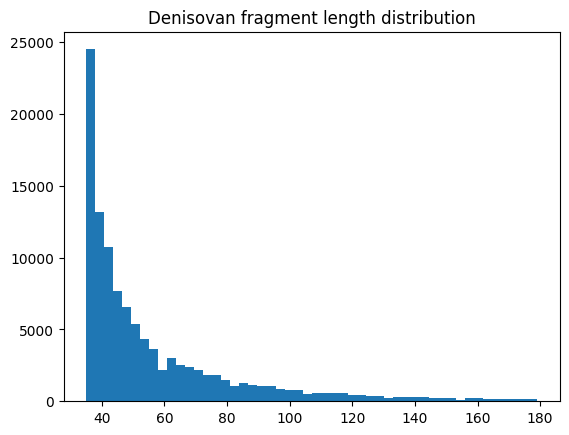

In [14]:
plt.hist(den_lengths, bins=50)
plt.title("Denisovan fragment length distribution")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

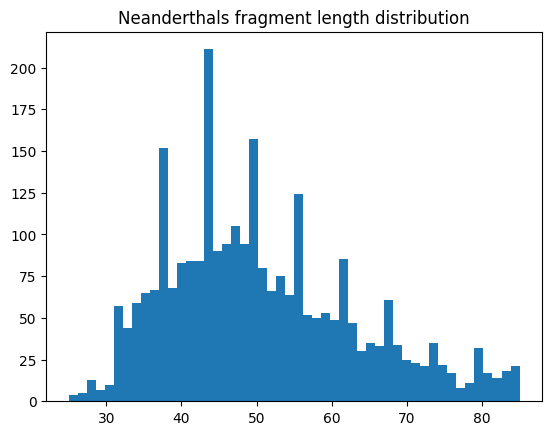

In [15]:
plt.hist(nea_lengths, bins=50)
plt.title("Neanderthals fragment length distribution")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

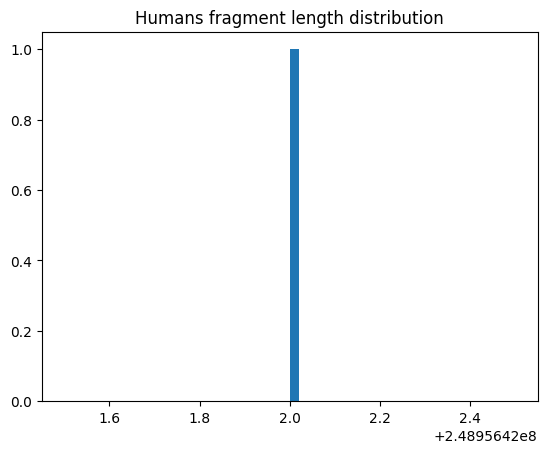

In [16]:
plt.hist(human_lengths, bins=50)
plt.title("Humans fragment length distribution")
plt.show

In [17]:
#this function will check the AGTCN frequencies
def base_composition(seqs):
    counts = Counter()
    for s in seqs:
        counts.update(s)
    total = sum(counts.values())
    for base in counts:
        print(base,counts[base]/total)

print("Denisovan compositoon")
base_composition(den_chr1[:10000])

Denisovan compositoon
A 0.2998472254402224
G 0.19659225845690453
T 0.29496893825301207
C 0.20855899559777571
N 3.2582252085264136e-05


In [18]:
print("Neanderthal composition")
base_composition(nea_chr1[:10000])

Neanderthal composition
C 0.2423095125414103
G 0.24114070186005823
A 0.25982016090866067
T 0.25672962468987076


In [19]:
print("Human composition")
base_composition([human_chr1[0][:100000]])

Human composition
N 0.1
T 0.25058
A 0.26735
C 0.19924
G 0.18283


In [20]:
# now we are doing a fucntion that checks
#the amount of n in each of this
#since in our previous analysis we saw that human genomes has a lot of 
#n values so we need to check it too 
def n_fraction(seqs):
    total = 0
    ncount = 0
    for s in seqs:
        total += len(s)
        ncount += s.count("N")
    print("N fraction:", ncount/total)

In [21]:
print("Denisovan")
n_fraction(den_chr1[:10000])

print("Neanderthal")
n_fraction(nea_chr1[:10000])

print("Human")
n_fraction([human_chr1[0][:100000]])

Denisovan
N fraction: 3.2582252085264136e-05
Neanderthal
N fraction: 0.0
Human
N fraction: 0.1
